In [11]:
import yfinance as yf
import QuantLib as ql
import numpy as np
import pandas as pd
from math import log, sqrt, exp
from scipy.stats import norm
import scipy.optimize as opt
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


In [5]:
# SVI total implied variance function
def svi_total_variance(params, k):
    a, b, rho, m, sigma = params
    return a + b * (rho * (k - m) + np.sqrt((k - m) ** 2 + sigma ** 2))

# Objective function for SVI calibration (Mean Squared Error)
def svi_objective(params, k, market_variance):
    model_variance = svi_total_variance(params, k)
    return np.sum((market_variance - model_variance) ** 2)  # Minimize MSE

In [2]:
# Generate synthetic implied volatility data (Replace with QuantLib data)
strikes = np.linspace(80, 120, 10)  # Strike prices
F = 100  # ATM Forward price
T = 1.0  # 1-year expiry
market_vols = np.random.rand(10) * 0.2 + 0.1  # Simulated implied volatilities
log_moneyness = np.log(strikes / F)
market_variance = (market_vols ** 2) * T  # Convert vols to total variance

In [4]:
market_vols

array([0.21044504, 0.13314796, 0.24945091, 0.24649195, 0.24162852,
       0.20508154, 0.18978691, 0.29855133, 0.16862929, 0.27123621])

In [8]:
# Initial SVI parameter guess: (a, b, rho, m, sigma)
initial_guess = [0.1, 0.1, 0.0, 0.0, 0.1]
bounds = [(0, None), (0, None), (-1, 1), (-np.inf, np.inf), (0, None)]

# Optimize SVI parameters
result = opt.minimize(svi_objective, initial_guess, args=(log_moneyness, market_variance), bounds=bounds, method='L-BFGS-B')
a, b, rho, m, sigma = result.x

# Compute fitted SVI variance
fitted_variance = svi_total_variance(result.x, log_moneyness)
fitted_vols = np.sqrt(fitted_variance / T)  # Convert back to implied volatility

print(f"Optimized SVI Parameters: a={a:.4f}, b={b:.4f}, rho={rho:.4f}, m={m:.4f}, sigma={sigma:.4f}")

Optimized SVI Parameters: a=0.0513, b=0.0000, rho=0.0071, m=-0.0279, sigma=0.0344


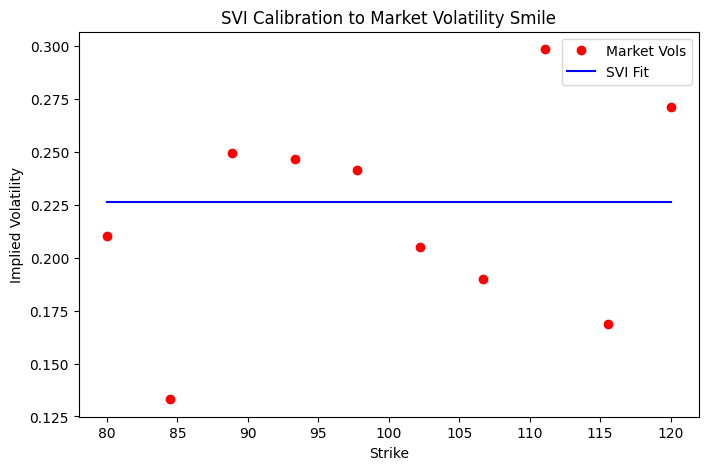

In [9]:
# Plot Market vs. Fitted Volatility
plt.figure(figsize=(8, 5))
plt.plot(strikes, market_vols, 'ro', label="Market Vols")
plt.plot(strikes, fitted_vols, 'b-', label="SVI Fit")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.title("SVI Calibration to Market Volatility Smile")
plt.legend()
plt.show()

In [12]:
import numpy as np
from scipy.optimize import minimize

def sabr_iv(alpha, beta, rho, nu, F, K, T):
    """ SABR Approximation for implied volatility """
    if K == F:  # ATM formula
        term1 = alpha / (F ** (1 - beta))
        term2 = 1 + ((2 - 3*rho**2) * nu**2 * T) / 24
        return term1 * term2
    else:
        z = (nu / alpha) * (K * F) ** ((1 - beta) / 2) * np.log(K / F)
        x_z = np.log((np.sqrt(1 - 2 * rho * z + z ** 2) + z - rho) / (1 - rho))
        term1 = (alpha / ((K * F) ** ((1 - beta) / 2)))
        term2 = z / x_z
        term3 = 1 + ((2 - 3 * rho ** 2) * nu ** 2 * T) / 24
        return term1 * term2 * term3

In [13]:
def sabr_calibrate(strikes, maturities, market_vols, F):
    """ Optimize SABR parameters by minimizing squared error """
    def objective(params):
        alpha, beta, rho, nu = params
        sabr_vols = np.array([[sabr_iv(alpha, beta, rho, nu, F, K, T)
                                for K in strikes] for T in maturities])
        return np.sum((market_vols - sabr_vols) ** 2)  # MSE
    
    # Initial guess: Alpha=0.2, Beta=0.5, Rho=0.0, Nu=0.2
    initial_guess = [0.2, 0.5, 0.0, 0.2]
    bounds = [(0.01, 1.0), (0, 1), (-1, 1), (0.01, 2.0)]
    
    result = minimize(objective, initial_guess, bounds=bounds, method='L-BFGS-B')
    return result.x  # Returns optimized (alpha, beta, rho, nu)

In [14]:
# Example Data (Replace with real implied vol surface from QuantLib)
strikes = np.linspace(80, 120, 10)  # Strike prices
maturities = np.linspace(0.1, 2, 10)  # Maturities in years
market_vols = np.random.rand(10, 10) * 0.2 + 0.1  # Simulated implied vols

# Assume at-the-money forward price F = 100
F = 100

# Optimize SABR parameters
alpha, beta, rho, nu = sabr_calibrate(strikes, maturities, market_vols, F)
print(f"Calibrated SABR Parameters: alpha={alpha:.3f}, beta={beta:.3f}, rho={rho:.3f}, nu={nu:.3f}")

Calibrated SABR Parameters: alpha=0.203, beta=1.000, rho=-1.000, nu=0.061


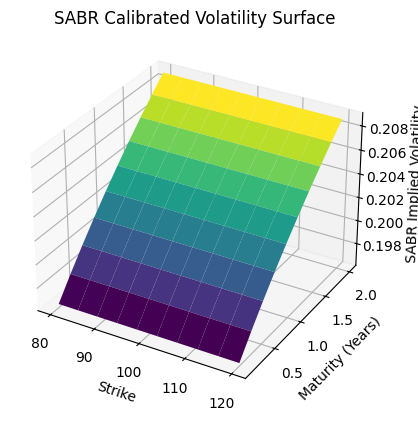

In [17]:
# Generate SABR-implied volatility surface
sabr_vol_surface = np.array([[sabr_iv(alpha, beta, rho, nu, F, K, T) for K in strikes] for T in maturities])

# Plot the surface
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
X, Y = np.meshgrid(strikes, maturities)
ax.plot_surface(X, Y, sabr_vol_surface.T, cmap='viridis')

ax.set_xlabel('Strike')
ax.set_ylabel('Maturity (Years)')
ax.set_zlabel('SABR Implied Volatility')
ax.set_title('SABR Calibrated Volatility Surface')

plt.show()